In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("../DataSets/ford-card-price-prediction.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [11]:
df.shape

(17966, 9)

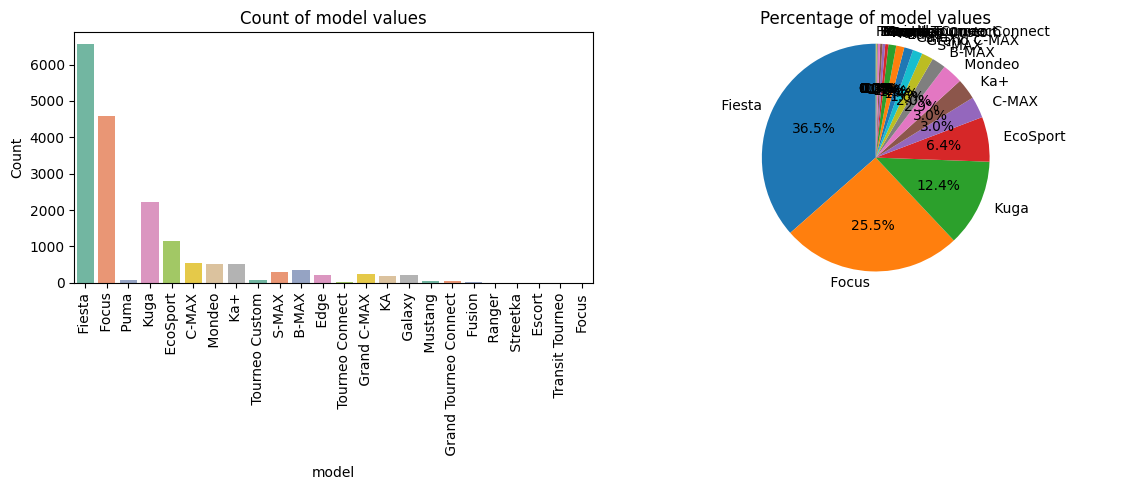

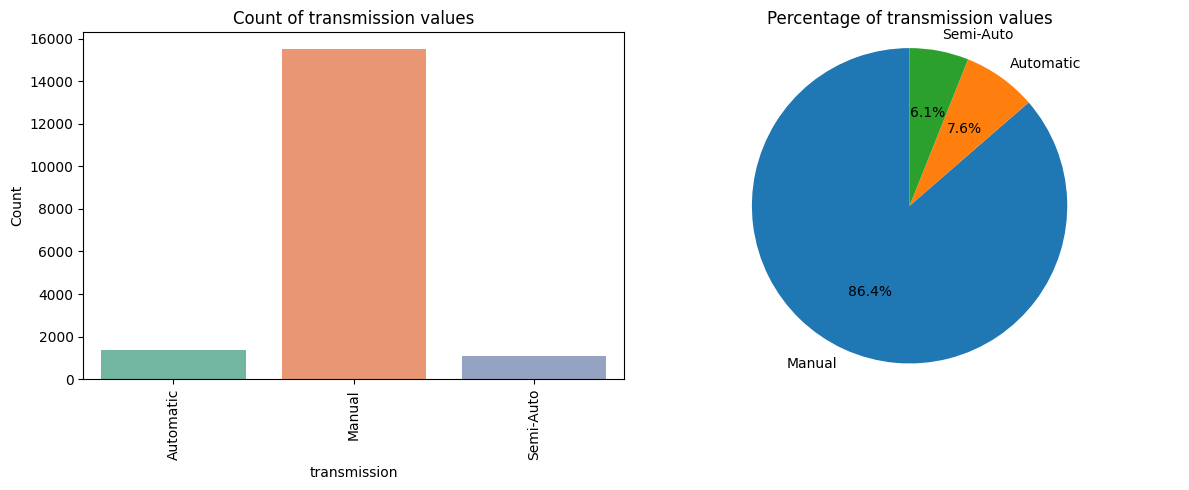

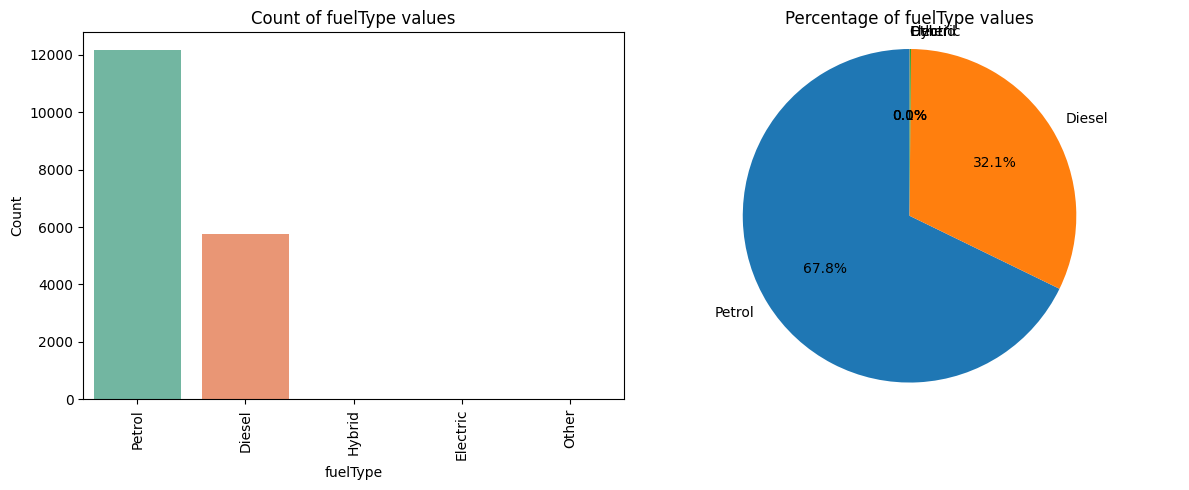

In [12]:
catgorical_values = df.select_dtypes(include=["object"])

for catgorical in catgorical_values:
    counts = df[catgorical].value_counts()
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)
    sns.countplot(data = df, x = catgorical, palette = "Set2")
    plt.title(f"Count of {catgorical} values")
    plt.xticks(rotation = 90)
    plt.ylabel("Count")
    # plt.show()

    plt.subplot(1,2,2)
    # plt.figure(figsize = (12,5))
    plt.pie(counts,labels=counts.index,autopct='%1.1f%%',startangle=90)
    plt.title(f"Percentage of {catgorical} values")
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.show()
    print("\n")

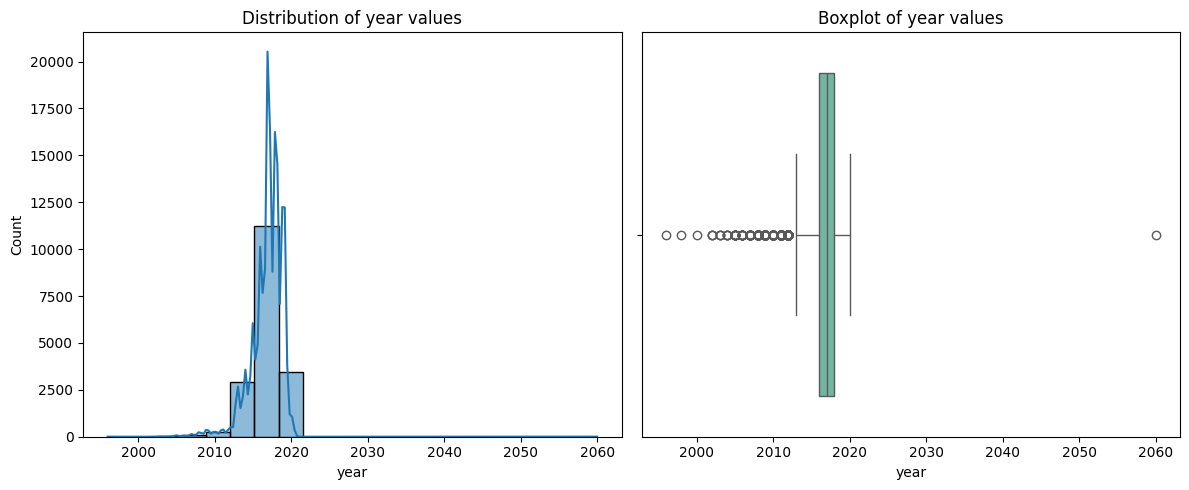

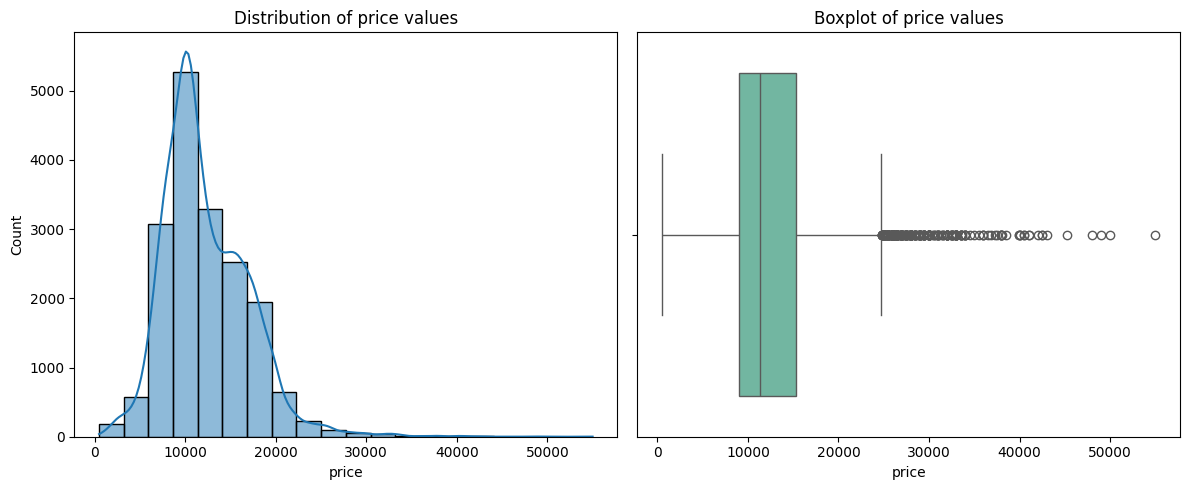

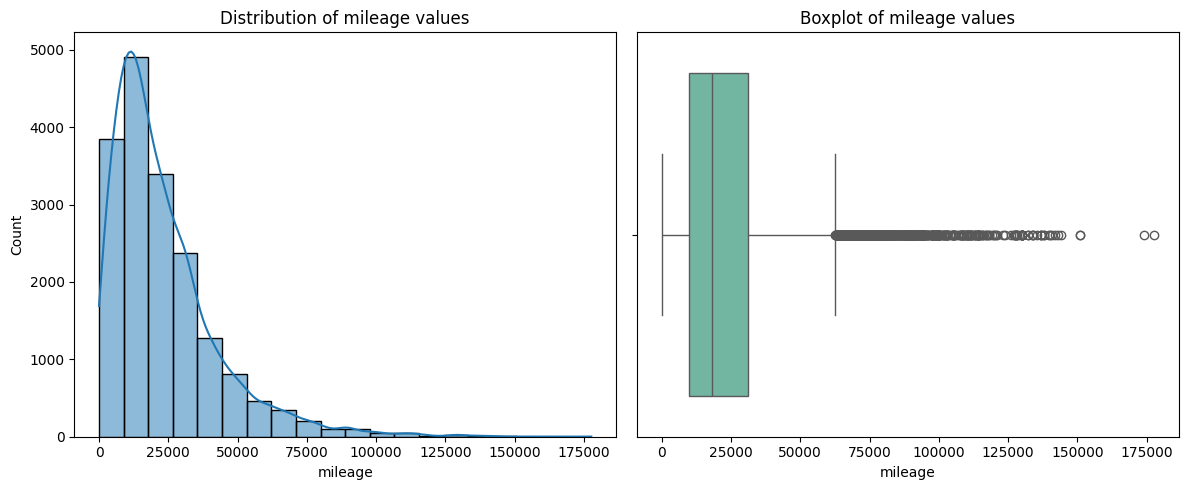

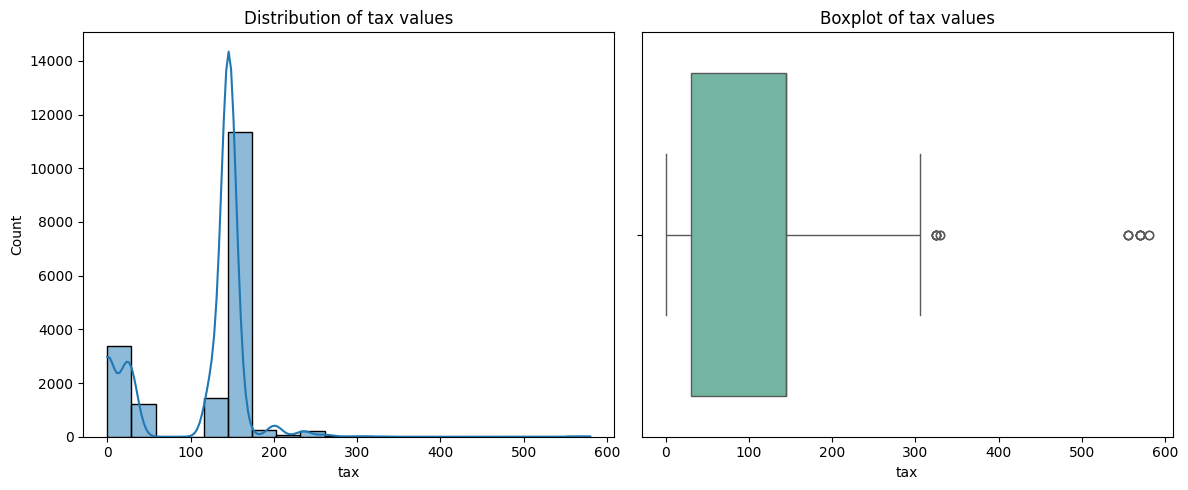

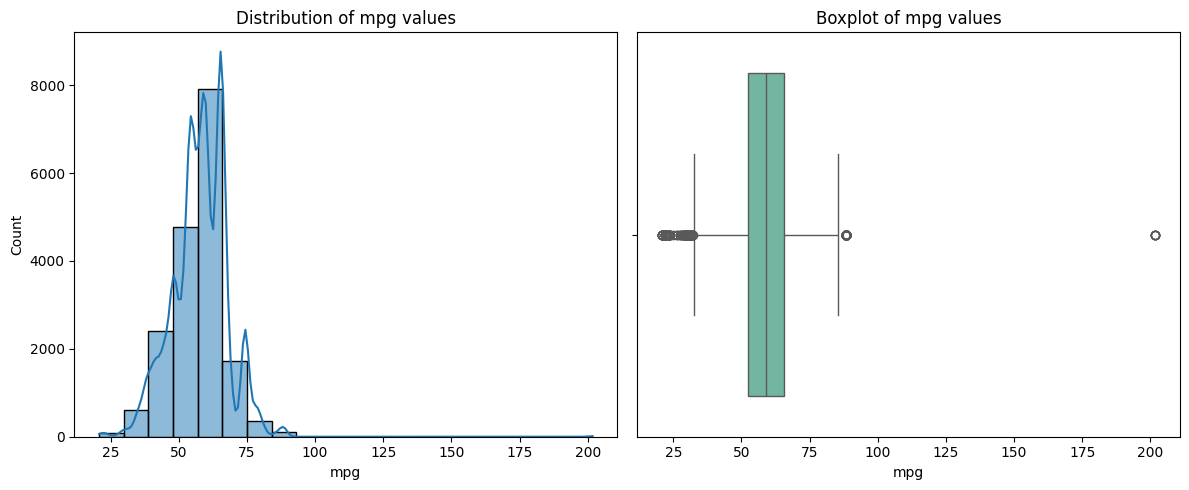

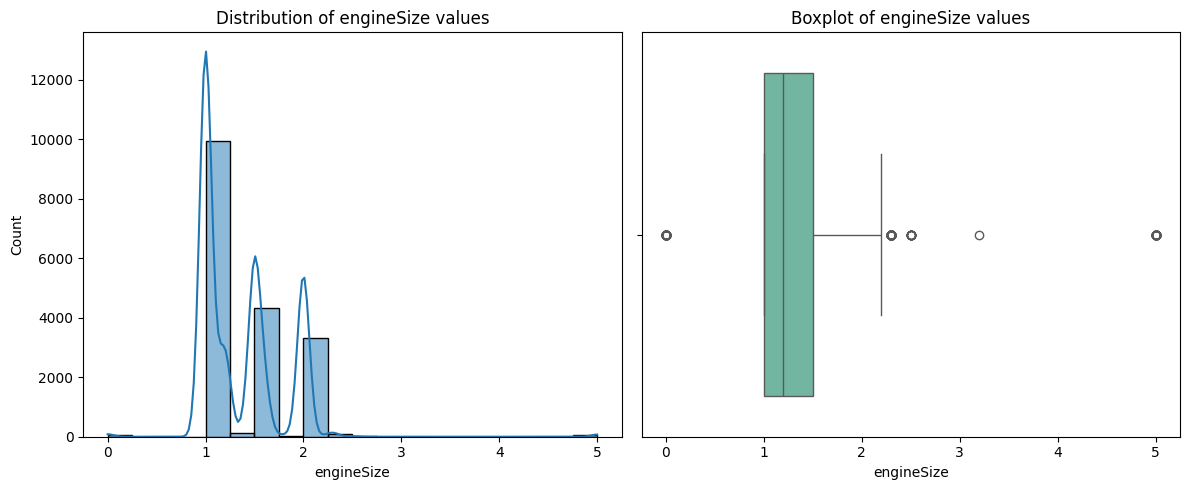

In [13]:
num_values = df.select_dtypes(include = ["int64", "float64"])
for num in num_values:
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)
    sns.histplot(data = df,x = num,kde = True,palette = "Set2",bins=20)
    plt.title(f"Distribution of {num} values")
    plt.xlabel(num)
    plt.ylabel("Count")
    # plt.show()

    plt.subplot(1,2,2)
    sns.boxplot(data = df,x = num,palette = "Set2")
    plt.title(f"Boxplot of {num} values")
    plt.xlabel(num)
    # plt.show()
    plt.tight_layout()
    plt.show()

In [14]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(154)

<Axes: >

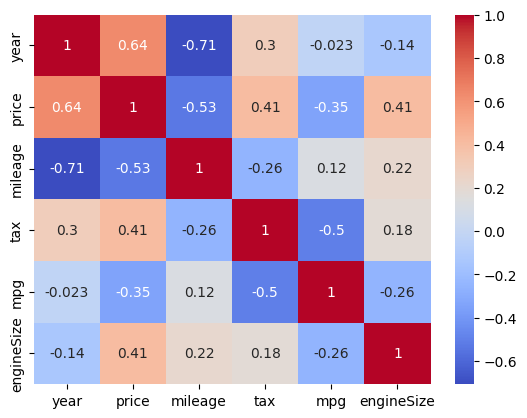

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = "coolwarm")

In [18]:
X = df.drop("price", axis = 1)
y = df["price"]

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [20]:
X_encoded = pd.get_dummies(X, columns=["fuelType", "transmission", "model"], drop_first=True)

In [21]:
X_encoded.head()

,year,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,15944,150,57.7,1.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,9083,150,57.7,1.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2017,12456,150,57.7,1.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2019,10460,145,40.3,1.5,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2019,1482,145,48.7,1.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
X_encoded = X_encoded.astype(int)

In [23]:
X_encoded.head()

,year,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,15944,150,57,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2018,9083,150,57,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,2017,12456,150,57,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,2019,10460,145,40,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,2019,1482,145,48,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()

columns = ["fuelType", "transmission", "model"]
X_label_encoded = X

for i in columns:
    le = LabelEncoder()
    X_label_encoded[i] = le.fit_transform(X_label_encoded[i])

In [27]:
X_label_encoded["model"].value_counts()

model
5     6557
6     4588
13    2225
2     1143
1      543
12     531
14     526
0      355
18     296
9      247
8      228
3      208
11     199
16      80
21      69
10      59
15      57
20      33
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [28]:
X_label_encoded.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [30]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [37]:
numeric_cols = ["year", "mileage", "engineSize", "tax", "mpg"]

X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
X_label_encoded[numeric_cols] = scaler.fit_transform(X_label_encoded[numeric_cols])

In [38]:
X_encoded.head()

,year,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
X_label_encoded.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,0.065128,0,-0.380998,4,0.591358,-0.020442,-0.811386
1,6,0.552866,1,-0.733359,4,0.591358,-0.020442,-0.811386
2,6,0.065128,1,-0.560132,4,0.591358,-0.020442,-0.811386
3,5,1.040605,1,-0.662640,4,0.510727,-1.738890,0.345070
4,5,1.040605,0,-1.123724,4,0.510727,-0.909294,-0.811386


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size = 0.2, random_state = 42)

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_test)

In [44]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

R-squared: 0.8464
Mean Squared Error: 3442092.8490
Mean Absolute Error: 1371.1901


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_label_encoded, y, test_size = 0.2, random_state = 42)

model2 = LinearRegression()

In [46]:
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred = model2.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

R-squared: 0.7366
Mean Squared Error: 5903593.7449
Mean Absolute Error: 1776.8255
